# Benchmark data generation — multi-puck (4 case + 4 control)

Extends `B.1.benchmark_posPC2.ipynb` to produce **4 matched case/control pairs** using
Slide-seq pucks 01, 04, 06, 07 from the mouse brain atlas.
(Pucks 02, 05, 08, 09 have a rotated orientation and are excluded.)

Having G = 8 clusters makes cluster-robust standard errors substantially more reliable
than the 2-sample version.

**Strategy per puck:**
1. Load puck, filter to tissue beads (`IsOutsideCCF == 0`)
2. Split at the Y-axis **median bead coordinate** → top half = **control**, bottom half = **case** (equal bead counts)
3. Define a central circle capturing exactly **15 % of bottom-half beads**, centred on the tissue centroid
4. Perturb the top-100 positive-PC2 genes inside the circle with Poisson noise (scale×5, min λ=1)
5. Save `adata_puck{XX}_top.h5ad` (control) and `adata_puck{XX}_bot_case_posPC2.h5ad` (case)

In [5]:
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DATA_DIR = Path('/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/benchmark/All_Pucks_h5ad')
OUT_DIR  = Path('/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/benchmark/generated_benchmark_data')
OUT_DIR.mkdir(exist_ok=True)

## 1. Load PC2 gene list (precomputed from puck 06)

In [6]:
top100_df  = pd.read_csv(OUT_DIR / 'top100_posPC2_genes.csv')
pc2_genes  = top100_df['gene'].values
print(f'Loaded {len(pc2_genes)} PC2 genes: {list(pc2_genes[:5])} ...')
print(f'All loadings positive: {(top100_df["pc2_loading"] > 0).all()}')

Loaded 100 PC2 genes: ['Camk1d', 'Lars2', 'Gm48099', 'Col6a6', 'Fabp7'] ...
All loadings positive: True


## 2. Helper functions

In [7]:
PERTURBATION_SCALE = 5.0
MIN_LAM            = 1.0


def clean_for_save(adata):
    """Remove raw slot and fix _index column name so anndata can write the file."""
    a = adata.copy()
    a.raw = None
    a.var = a.var.rename(columns={'_index': 'gene_id'})
    if a.var.index.name == '_index':
        a.var.index.name = None
    return a


def split_puck(adata):
    """Split at the median bead Y coordinate → equal bead counts in each half.
    Using the median rather than the bounding-box midpoint prevents one half from
    containing almost no tissue when beads cluster near one edge."""
    y       = adata.obs['Raw_Slideseq_Y'].values.astype(float)
    split_y = np.median(y)

    top = adata[y <= split_y].copy()
    bot = adata[y >  split_y].copy()

    # Flip bottom vertically so its orientation mirrors the top
    y_bot = bot.obs['Raw_Slideseq_Y'].values.astype(float)
    bot.obs['Raw_Slideseq_Y'] = y_bot.max() + y_bot.min() - y_bot

    return top, bot, split_y


def add_circle_mask(adata_bot, target_fraction=0.15):
    """Circle capturing *exactly* target_fraction of bottom-half beads.

    Two fixes vs. the bounding-box formula:
    - Centre = mean bead position (tissue centroid), not bounding-box midpoint.
      The midpoint often falls on tissue gaps (ventricles, fissures, medial lines).
    - Radius = target_fraction quantile of bead distances from the centre.
      This guarantees the fraction regardless of tissue shape."""
    x   = adata_bot.obs['Raw_Slideseq_X'].values.astype(float)
    y   = adata_bot.obs['Raw_Slideseq_Y'].values.astype(float)

    cx  = np.mean(x)          # tissue centroid
    cy  = np.mean(y)

    dist   = np.sqrt((x - cx)**2 + (y - cy)**2)
    circ_r = np.quantile(dist, target_fraction)   # exact target fraction

    in_circ = dist <= circ_r
    adata_bot.obs['in_circle'] = in_circ
    return in_circ, (cx, cy, circ_r)


def perturb_circle(adata_bot, pc2_genes, seed):
    """Apply Poisson perturbation to PC2 genes inside the circle."""
    adata_case  = adata_bot.copy()
    circle_idx  = np.where(adata_case.obs['in_circle'].values)[0]
    feat_to_col = {g: i for i, g in enumerate(adata_case.var['features'])}
    gene_cols   = np.array([feat_to_col[g] for g in pc2_genes if g in feat_to_col])

    X_sub = adata_case.X[np.ix_(circle_idx, gene_cols)]
    if sp.issparse(X_sub):
        X_sub = X_sub.toarray()
    X_sub = X_sub.astype(np.float32)

    lam       = np.maximum(X_sub.mean(axis=0) * PERTURBATION_SCALE, MIN_LAM)
    rng       = np.random.default_rng(seed)
    additions = rng.poisson(lam[np.newaxis, :], size=X_sub.shape).astype(np.float32)

    row_idx = np.repeat(circle_idx, len(gene_cols))
    col_idx = np.tile(gene_cols,    len(circle_idx))
    delta   = sp.csr_matrix(
        (additions.flatten(), (row_idx, col_idx)),
        shape=adata_case.X.shape, dtype=np.float32
    )
    adata_case.X = (adata_case.X + delta).tocsr()
    return adata_case, len(gene_cols)

## 3. Generate 5 case / control pairs (pucks 02–06)

Puck 06 reuses the file already saved by `B.1.benchmark_posPC2.ipynb` — its split and
perturbation are reproduced here with the same seed (28 + 6 = 34) for consistency.  
Files are saved as `adata_puck{XX}_top.h5ad` and `adata_puck{XX}_bot_case_posPC2.h5ad`.


── Puck 01 ──────────────────────────────
  Loaded: 59,503 tissue beads
  Split at Y=3474.8:  top=29,753  bot=29,750
  Circle centre=(4602,4903) r=639: 4,463 beads (15.0%)
  Perturbed 99 genes  (seed=29)
  Saved: adata_puck01_top.h5ad  (212 MB)
  Saved: adata_puck01_bot_case_posPC2.h5ad  (216 MB)

── Puck 04 ──────────────────────────────
  Loaded: 75,307 tissue beads
  Split at Y=3815.7:  top=37,654  bot=37,653
  Circle centre=(4922,5763) r=725: 5,648 beads (15.0%)
  Perturbed 98 genes  (seed=32)
  Saved: adata_puck04_top.h5ad  (132 MB)
  Saved: adata_puck04_bot_case_posPC2.h5ad  (124 MB)

── Puck 06 ──────────────────────────────
  Loaded: 79,800 tissue beads
  Split at Y=2534.9:  top=39,900  bot=39,900
  Circle centre=(3395,3589) r=392: 5,985 beads (15.0%)
  Perturbed 100 genes  (seed=34)
  Saved: adata_puck06_top.h5ad  (88 MB)
  Saved: adata_puck06_bot_case_posPC2.h5ad  (108 MB)

── Puck 07 ──────────────────────────────
  Loaded: 86,083 tissue beads
  Split at Y=2196.5:  top=43,0

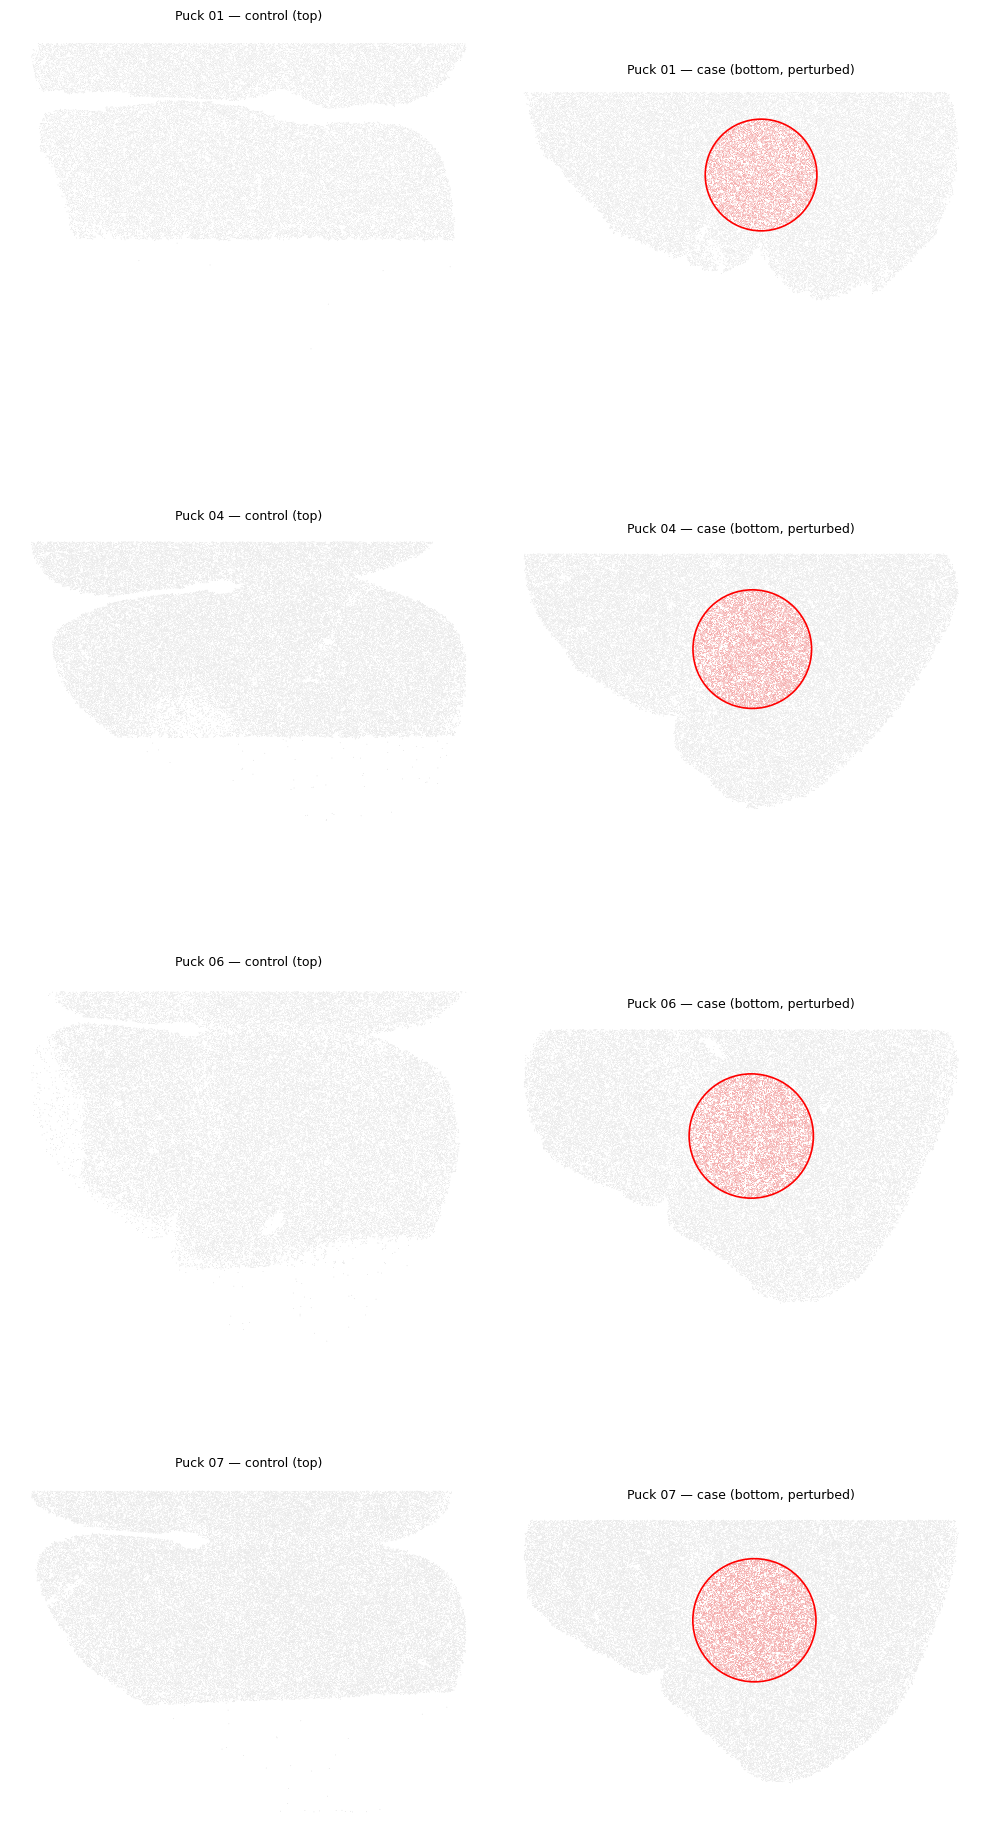


── Summary ─────────────────────────────────────
puck_id  ctrl_beads  case_beads  circle_beads circle_pct  genes_perturbed
     01       29753       29750          4463      15.0%               99
     04       37654       37653          5648      15.0%               98
     06       39900       39900          5985      15.0%              100
     07       43046       43037          6456      15.0%               97


In [8]:
PUCK_IDS = ['01', '04', '06', '07']   # 4 pucks - G = 8 clusters total

summary = []

fig, axes = plt.subplots(len(PUCK_IDS), 2, figsize=(10, 5 * len(PUCK_IDS)))

for row_idx_plt, puck_id in enumerate(PUCK_IDS):
    print(f'\n── Puck {puck_id} ──────────────────────────────')

    # Load
    adata = ad.read_h5ad(DATA_DIR / f'Puck_Num_{puck_id}.h5ad')
    adata = adata[adata.obs['IsOutsideCCF'] == 0].copy()
    print(f'  Loaded: {adata.n_obs:,} tissue beads')

    # Split at median Y → equal halves
    top, bot, split_y = split_puck(adata)
    print(f'  Split at Y={split_y:.1f}:  top={top.n_obs:,}  bot={bot.n_obs:,}')

    # Circle: tissue centroid + quantile radius → exactly 15% of beads
    in_circ, (cx, cy, circ_r) = add_circle_mask(bot, target_fraction=0.15)
    print(f'  Circle centre=({cx:.0f},{cy:.0f}) r={circ_r:.0f}: '
          f'{in_circ.sum():,} beads ({in_circ.mean():.1%})')

    # Perturb
    seed = 28 + int(puck_id)
    case, n_genes_perturbed = perturb_circle(bot, pc2_genes, seed=seed)
    print(f'  Perturbed {n_genes_perturbed} genes  (seed={seed})')

    # Save
    ctrl_path = OUT_DIR / f'adata_puck{puck_id}_top.h5ad'
    case_path = OUT_DIR / f'adata_puck{puck_id}_bot_case_posPC2.h5ad'
    clean_for_save(top).write_h5ad(ctrl_path)
    clean_for_save(case).write_h5ad(case_path)
    print(f'  Saved: {ctrl_path.name}  ({ctrl_path.stat().st_size/1e6:.0f} MB)')
    print(f'  Saved: {case_path.name}  ({case_path.stat().st_size/1e6:.0f} MB)')

    summary.append({
        'puck_id':          puck_id,
        'ctrl_beads':       top.n_obs,
        'case_beads':       case.n_obs,
        'circle_beads':     int(in_circ.sum()),
        'circle_pct':       f'{in_circ.mean():.1%}',
        'genes_perturbed':  n_genes_perturbed,
    })

    # Spatial check
    ax_ctrl = axes[row_idx_plt][0]
    ax_case = axes[row_idx_plt][1]
    for ax, adata_plot, label in [
        (ax_ctrl, top,  f'Puck {puck_id} — control (top)'),
        (ax_case, case, f'Puck {puck_id} — case (bottom, perturbed)'),
    ]:
        x_p    = adata_plot.obs['Raw_Slideseq_X'].values.astype(float)
        y_p    = adata_plot.obs['Raw_Slideseq_Y'].values.astype(float)
        c_p    = adata_plot.obs.get('in_circle', pd.Series([False] * len(adata_plot)))
        colors = np.where(c_p, '#e84545', '#d3d3d3')
        ax.scatter(x_p, y_p, c=colors, s=0.3, linewidths=0, rasterized=True)
        ax.set_aspect('equal', 'box')
        ax.axis('off')
        ax.set_title(label, fontsize=9)

    axes[row_idx_plt][1].add_patch(
        plt.Circle((cx, cy), circ_r, fill=False, edgecolor='red', linewidth=1.2)
    )

plt.tight_layout()
plt.savefig(OUT_DIR / 'multi_puck_overview.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n── Summary ─────────────────────────────────────')
print(pd.DataFrame(summary).to_string(index=False))

## 4. Verify: check a sim gene across all case samples

Checking Camk1d across all generated samples...


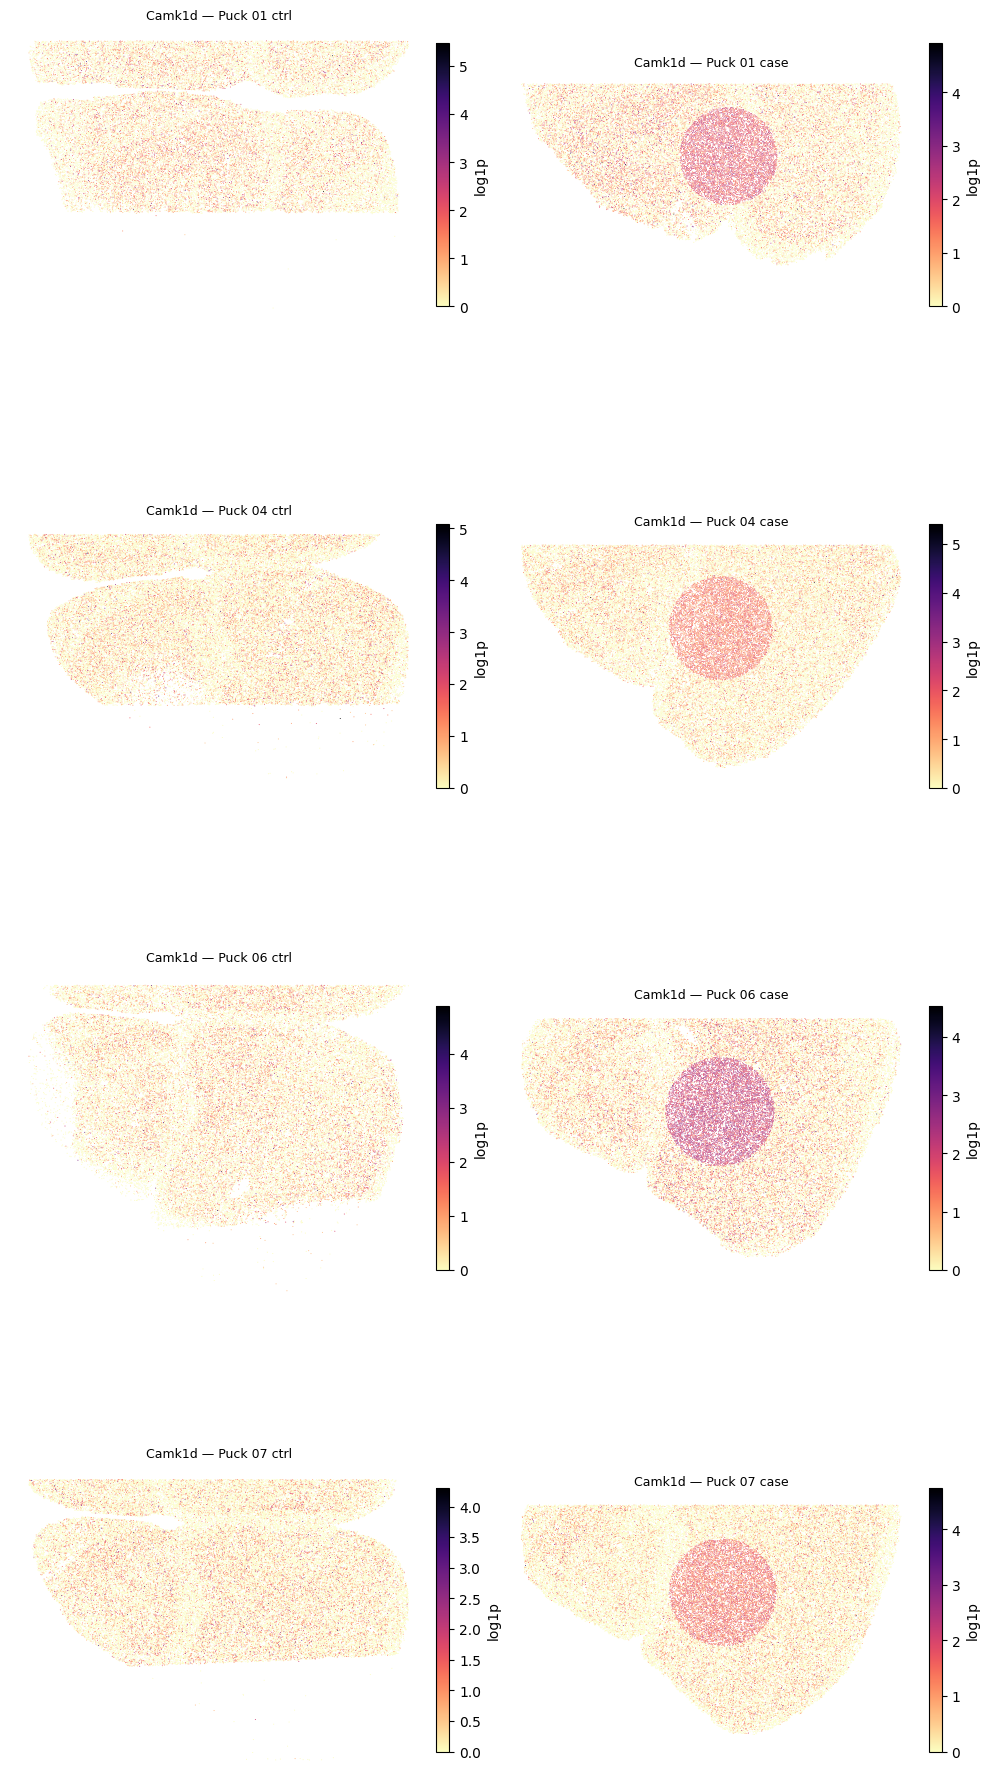

In [9]:
CHECK_GENE = pc2_genes[0]   # strongest PC2 gene (Camk1d)
print(f'Checking {CHECK_GENE} across all generated samples...')

fig, axes = plt.subplots(len(PUCK_IDS), 2, figsize=(10, 5 * len(PUCK_IDS)))

for row_i, puck_id in enumerate(PUCK_IDS):
    for col_i, (fname, label) in enumerate([
        (f'adata_puck{puck_id}_top.h5ad',              f'Puck {puck_id} ctrl'),
        (f'adata_puck{puck_id}_bot_case_posPC2.h5ad',  f'Puck {puck_id} case'),
    ]):
        adata_check = ad.read_h5ad(OUT_DIR / fname)
        feat_map    = dict(zip(adata_check.var['features'], adata_check.var_names))
        if CHECK_GENE not in feat_map:
            axes[row_i][col_i].set_title(f'{CHECK_GENE} not found')
            axes[row_i][col_i].axis('off')
            continue
        expr = adata_check[:, feat_map[CHECK_GENE]].X
        if sp.issparse(expr):
            expr = expr.toarray().flatten()
        else:
            expr = np.asarray(expr).flatten()
        expr = np.log1p(expr)
        x_p  = adata_check.obs['Raw_Slideseq_X'].values.astype(float)
        y_p  = adata_check.obs['Raw_Slideseq_Y'].values.astype(float)
        ax   = axes[row_i][col_i]
        sc   = ax.scatter(x_p, y_p, c=expr, s=0.5, cmap='magma_r',
                          linewidths=0, rasterized=True)
        plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='log1p')
        ax.set_aspect('equal', 'box')
        ax.axis('off')
        ax.set_title(f'{CHECK_GENE} — {label}', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Final file listing

In [10]:
print('Generated benchmark files:')
for f in sorted(OUT_DIR.glob('adata_puck*.h5ad')):
    role = 'CTRL' if '_top' in f.name else 'CASE'
    print(f'  [{role}]  {f.name}  ({f.stat().st_size/1e6:.0f} MB)')

print(f'\nTotal: {len(PUCK_IDS)} case + {len(PUCK_IDS)} control samples  →  G = {2*len(PUCK_IDS)} clusters')
print('Ready for B.2 analysis with cluster-robust SEs.')

Generated benchmark files:
  [CASE]  adata_puck01_bot_case_posPC2.h5ad  (216 MB)
  [CTRL]  adata_puck01_top.h5ad  (212 MB)
  [CASE]  adata_puck02_bot_case_posPC2.h5ad  (151 MB)
  [CTRL]  adata_puck02_top.h5ad  (83 MB)
  [CASE]  adata_puck03_bot_case_posPC2.h5ad  (190 MB)
  [CTRL]  adata_puck03_top.h5ad  (140 MB)
  [CASE]  adata_puck04_bot_case_posPC2.h5ad  (124 MB)
  [CTRL]  adata_puck04_top.h5ad  (132 MB)
  [CASE]  adata_puck05_bot_case_posPC2.h5ad  (92 MB)
  [CTRL]  adata_puck05_top.h5ad  (80 MB)
  [CASE]  adata_puck06_bot_case_posPC2.h5ad  (108 MB)
  [CTRL]  adata_puck06_top.h5ad  (88 MB)
  [CASE]  adata_puck07_bot_case_posPC2.h5ad  (142 MB)
  [CTRL]  adata_puck07_top.h5ad  (147 MB)

Total: 4 case + 4 control samples  →  G = 8 clusters
Ready for B.2 analysis with cluster-robust SEs.
